In [12]:
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import random
from sklearn.metrics import mean_squared_error, mean_absolute_error

# Set random seeds for reproducibility
torch.manual_seed(42)
np.random.seed(42)

# Configuration
NUM_SAMPLES = 1000  # Sample dataset size
TEXT_EMBED_DIM = 768  # Typical BERT embedding size
IMAGE_EMBED_DIM = 2048  # Typical ResNet embedding size
RATING_RANGE = (0, 5)  # Movie rating scale 0-5
BATCH_SIZE = 32
LEARNING_RATE = 0.001

print("Configuration set up for movie rating prediction!")

Configuration set up for movie rating prediction!


In [13]:
# Generate random embeddings for movie rating prediction
def generate_random_movie_data(num_samples, text_dim, image_dim, rating_range):
    """Generate random text, image embeddings and user ratings"""

    # Random text embeddings (simulating BERT/CLIP text embeddings from movie descriptions)
    text_embeddings = torch.randn(num_samples, text_dim)

    # Random image embeddings (simulating ResNet/ViT embeddings from movie posters)
    image_embeddings = torch.randn(num_samples, image_dim)

    # Generate realistic user ratings (0-5 scale)
    # Create a more realistic distribution with some bias towards middle ratings
    ratings = torch.zeros(num_samples)

    for i in range(num_samples):
        # Simulate realistic rating distribution (more 3-4 star ratings)
        rating = np.random.normal(3.5, 1.2)  # Center around 3.5 with some variance
        rating = np.clip(rating, rating_range[0], rating_range[1])
        ratings[i] = rating

    # Add some correlation between embeddings and ratings for more realistic simulation
    # Higher quality embeddings (by magnitude) tend to have higher ratings
    text_quality = torch.norm(text_embeddings, dim=1)
    image_quality = torch.norm(image_embeddings, dim=1)
    combined_quality = (text_quality + image_quality) / 2

    # Adjust ratings based on embedding quality
    quality_adjustment = (combined_quality - combined_quality.mean()) * 0.3
    ratings = torch.clamp(ratings + quality_adjustment, rating_range[0], rating_range[1])

    return text_embeddings, image_embeddings, ratings

# Generate sample data
text_embeds, image_embeds, user_ratings = generate_random_movie_data(
    NUM_SAMPLES, TEXT_EMBED_DIM, IMAGE_EMBED_DIM, RATING_RANGE
)

print(f"Generated {NUM_SAMPLES} movie samples:")
print(f"Text embeddings shape: {text_embeds.shape}")
print(f"Image embeddings shape: {image_embeds.shape}")
print(f"User ratings shape: {user_ratings.shape}")
print(f"Rating statistics:")
print(f"  Mean: {user_ratings.mean():.2f}")
print(f"  Std: {user_ratings.std():.2f}")
print(f"  Min: {user_ratings.min():.2f}")
print(f"  Max: {user_ratings.max():.2f}")
print(f"  Rating distribution: {torch.bincount(user_ratings.long())}")

Generated 1000 movie samples:
Text embeddings shape: torch.Size([1000, 768])
Image embeddings shape: torch.Size([1000, 2048])
User ratings shape: torch.Size([1000])
Rating statistics:
  Mean: 3.45
  Std: 1.05
  Min: 0.00
  Max: 5.00
  Rating distribution: tensor([ 13,  82, 239, 338, 266,  62])


In [14]:
class MovieRatingDataset(Dataset):
    """Dataset class for multi-modal movie rating prediction"""

    def __init__(self, text_embeddings, image_embeddings, user_ratings):
        self.text_embeddings = text_embeddings
        self.image_embeddings = image_embeddings
        self.user_ratings = user_ratings

    def __len__(self):
        return len(self.text_embeddings)

    def __getitem__(self, idx):
        return {
            'text': self.text_embeddings[idx],
            'image': self.image_embeddings[idx],
            'rating': self.user_ratings[idx]
        }

def early_fusion(text_embeds, image_embeds):
    """
    Early Fusion: Concatenate text and image embeddings

    Args:
        text_embeds: Tensor of shape (batch_size, text_dim)
        image_embeds: Tensor of shape (batch_size, image_dim)

    Returns:
        fused_embeds: Tensor of shape (batch_size, text_dim + image_dim)
    """
    # Normalize embeddings to prevent scale imbalance
    text_embeds = nn.functional.normalize(text_embeds, p=2, dim=1)
    image_embeds = nn.functional.normalize(image_embeds, p=2, dim=1)

    # Concatenate along feature dimension
    fused_embeds = torch.cat([text_embeds, image_embeds], dim=1)

    return fused_embeds

# Test early fusion
sample_text = text_embeds[:4]
sample_image = image_embeds[:4]
fused = early_fusion(sample_text, sample_image)

print(f"Early Fusion Test:")
print(f"Text shape: {sample_text.shape}")
print(f"Image shape: {sample_image.shape}")
print(f"Fused shape: {fused.shape}")
print(f"Fused dimension: {TEXT_EMBED_DIM + IMAGE_EMBED_DIM}")

Early Fusion Test:
Text shape: torch.Size([4, 768])
Image shape: torch.Size([4, 2048])
Fused shape: torch.Size([4, 2816])
Fused dimension: 2816


In [15]:
class EarlyFusionRatingPredictor(nn.Module):
    """Neural network for movie rating prediction using early fusion"""

    def __init__(self, text_dim, image_dim, hidden_dims=[1024, 512, 256, 128]):
        super(EarlyFusionRatingPredictor, self).__init__()

        # Input dimension after fusion
        fused_dim = text_dim + image_dim

        # Build the regression layers
        layers = []
        prev_dim = fused_dim

        for hidden_dim in hidden_dims:
            layers.extend([
                nn.Linear(prev_dim, hidden_dim),
                nn.ReLU(),
                nn.Dropout(0.3),
                nn.BatchNorm1d(hidden_dim)
            ])
            prev_dim = hidden_dim

        # Output layer for regression (single value for rating prediction)
        layers.append(nn.Linear(prev_dim, 1))

        # Add activation to constrain output to rating range
        self.rating_min = 0.0
        self.rating_max = 5.0

        self.regressor = nn.Sequential(*layers)

    def forward(self, text_embeds, image_embeds):
        # Apply early fusion
        fused_embeds = early_fusion(text_embeds, image_embeds)

        # Pass through regressor
        rating_logits = self.regressor(fused_embeds)

        # Apply sigmoid and scale to rating range [0, 5]
        rating_pred = torch.sigmoid(rating_logits) * (self.rating_max - self.rating_min) + self.rating_min

        return rating_pred.squeeze()

# Initialize the model
model = EarlyFusionRatingPredictor(
    text_dim=TEXT_EMBED_DIM,
    image_dim=IMAGE_EMBED_DIM
)

print(f"Rating prediction model initialized with {sum(p.numel() for p in model.parameters())} parameters")
print(model)

Rating prediction model initialized with 3577601 parameters
EarlyFusionRatingPredictor(
  (regressor): Sequential(
    (0): Linear(in_features=2816, out_features=1024, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.3, inplace=False)
    (3): BatchNorm1d(1024, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (4): Linear(in_features=1024, out_features=512, bias=True)
    (5): ReLU()
    (6): Dropout(p=0.3, inplace=False)
    (7): BatchNorm1d(512, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (8): Linear(in_features=512, out_features=256, bias=True)
    (9): ReLU()
    (10): Dropout(p=0.3, inplace=False)
    (11): BatchNorm1d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (12): Linear(in_features=256, out_features=128, bias=True)
    (13): ReLU()
    (14): Dropout(p=0.3, inplace=False)
    (15): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (16): Linear(in_features=128, out_features=

In [16]:
# Split data into train and test sets
train_size = int(0.8 * NUM_SAMPLES)
test_size = NUM_SAMPLES - train_size

train_dataset = MovieRatingDataset(
    text_embeds[:train_size],
    image_embeds[:train_size],
    user_ratings[:train_size]
)

test_dataset = MovieRatingDataset(
    text_embeds[train_size:],
    image_embeds[train_size:],
    user_ratings[train_size:]
)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

print(f"Training set size: {len(train_dataset)}")
print(f"Test set size: {len(test_dataset)}")
print(f"Number of training batches: {len(train_loader)}")
print(f"Training rating stats: Mean={train_dataset.user_ratings.mean():.2f}, Std={train_dataset.user_ratings.std():.2f}")
print(f"Test rating stats: Mean={test_dataset.user_ratings.mean():.2f}, Std={test_dataset.user_ratings.std():.2f}")

Training set size: 800
Test set size: 200
Number of training batches: 25
Training rating stats: Mean=3.42, Std=1.06
Test rating stats: Mean=3.57, Std=1.03


In [17]:
# Display the first few samples of the training dataset
print("Training Dataset Head (First 5 Samples):")
print("=" * 60)

# Get first 5 samples from training dataset
for i in range(5):
    sample = train_dataset[i]
    text_embed = sample['text']
    image_embed = sample['image']
    rating = sample['rating']

    print(f"\nSample {i+1}:")
    print(f"  Rating: {rating:.2f}★")
    print(f"  Text Embedding Shape: {text_embed.shape}")
    print(f"  Text Embedding Stats: Mean={text_embed.mean():.3f}, Std={text_embed.std():.3f}, Min={text_embed.min():.3f}, Max={text_embed.max():.3f}")
    print(f"  Image Embedding Shape: {image_embed.shape}")
    print(f"  Image Embedding Stats: Mean={image_embed.mean():.3f}, Std={image_embed.std():.3f}, Min={image_embed.min():.3f}, Max={image_embed.max():.3f}")

    # Show first few values of each embedding for inspection
    print(f"  Text Embedding (first 10 values): {text_embed[:10].tolist()}")
    print(f"  Image Embedding (first 10 values): {image_embed[:10].tolist()}")

print("\n" + "=" * 60)
print("Dataset Summary:")
print(f"Total training samples: {len(train_dataset)}")
print(f"Text embedding dimension: {TEXT_EMBED_DIM}")
print(f"Image embedding dimension: {IMAGE_EMBED_DIM}")
print(f"Rating range: {RATING_RANGE}")
print(f"Training ratings distribution:")
rating_counts = torch.bincount(train_dataset.user_ratings.long())
for rating, count in enumerate(rating_counts):
    if count > 0:
        print(f"  {rating}★: {count} samples ({count/len(train_dataset)*100:.1f}%)")

Training Dataset Head (First 5 Samples):

Sample 1:
  Rating: 4.34★
  Text Embedding Shape: torch.Size([768])
  Text Embedding Stats: Mean=0.036, Std=0.999, Min=-2.794, Max=3.025
  Image Embedding Shape: torch.Size([2048])
  Image Embedding Stats: Mean=0.005, Std=1.037, Min=-4.237, Max=3.162
  Text Embedding (first 10 values): [1.9269152879714966, 1.4872840642929077, 0.9007171988487244, -2.1055209636688232, 0.6784184575080872, -1.2345448732376099, -0.04306747764348984, -1.6046669483184814, -0.7521352767944336, 1.6487230062484741]
  Image Embedding (first 10 values): [-0.0819447711110115, -0.2753708064556122, -1.0810238122940063, -0.8735848069190979, -0.3384152948856354, 1.6901384592056274, -1.8986639976501465, 1.8036972284317017, -0.27561092376708984, -0.03838468715548515]

Sample 2:
  Rating: 3.19★
  Text Embedding Shape: torch.Size([768])
  Text Embedding Stats: Mean=-0.027, Std=0.991, Min=-3.102, Max=3.446
  Image Embedding Shape: torch.Size([2048])
  Image Embedding Stats: Mean=0.0

In [18]:
# Training setup for regression
criterion = nn.MSELoss()  # Mean Squared Error for regression
optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE)
num_epochs = 15

# Training loop for rating prediction
def train_rating_model(model, train_loader, criterion, optimizer, num_epochs):
    model.train()
    train_losses = []

    for epoch in range(num_epochs):
        epoch_loss = 0.0
        num_batches = 0

        for batch in train_loader:
            text = batch['text']
            image = batch['image']
            ratings = batch['rating']

            # Forward pass
            predictions = model(text, image)
            loss = criterion(predictions, ratings)

            # Backward pass and optimize
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            epoch_loss += loss.item()
            num_batches += 1

        avg_loss = epoch_loss / num_batches
        train_losses.append(avg_loss)

        print(f'Epoch [{epoch+1}/{num_epochs}], MSE Loss: {avg_loss:.4f}')

    return train_losses

# Train the model
print("Starting rating prediction training...")
train_losses = train_rating_model(model, train_loader, criterion, optimizer, num_epochs)
print("Training completed!")

Starting rating prediction training...
Epoch [1/15], MSE Loss: 2.4101
Epoch [2/15], MSE Loss: 1.6528
Epoch [3/15], MSE Loss: 0.9956
Epoch [4/15], MSE Loss: 0.7630
Epoch [5/15], MSE Loss: 0.6031
Epoch [6/15], MSE Loss: 0.4970
Epoch [7/15], MSE Loss: 0.4112
Epoch [8/15], MSE Loss: 0.3649
Epoch [9/15], MSE Loss: 0.3303
Epoch [10/15], MSE Loss: 0.2965
Epoch [11/15], MSE Loss: 0.2972
Epoch [12/15], MSE Loss: 0.2786
Epoch [13/15], MSE Loss: 0.2335
Epoch [14/15], MSE Loss: 0.2105
Epoch [15/15], MSE Loss: 0.2108
Training completed!


In [19]:
class LateFusionRatingPredictor(nn.Module):
    """
    Late Fusion: Process text and image embeddings separately, then combine predictions
    """

    def __init__(self, text_dim, image_dim, hidden_dims=[512, 256, 128]):
        super(LateFusionRatingPredictor, self).__init__()

        # Text processing branch
        text_layers = []
        prev_dim = text_dim
        for hidden_dim in hidden_dims:
            text_layers.extend([
                nn.Linear(prev_dim, hidden_dim),
                nn.ReLU(),
                nn.Dropout(0.3),
                nn.BatchNorm1d(hidden_dim)
            ])
            prev_dim = hidden_dim
        text_layers.append(nn.Linear(prev_dim, 1))  # Single rating prediction from text
        self.text_branch = nn.Sequential(*text_layers)

        # Image processing branch
        image_layers = []
        prev_dim = image_dim
        for hidden_dim in hidden_dims:
            image_layers.extend([
                nn.Linear(prev_dim, hidden_dim),
                nn.ReLU(),
                nn.Dropout(0.3),
                nn.BatchNorm1d(hidden_dim)
            ])
            prev_dim = hidden_dim
        image_layers.append(nn.Linear(prev_dim, 1))  # Single rating prediction from image
        self.image_branch = nn.Sequential(*image_layers)

        # Fusion layer to combine text and image predictions
        self.fusion = nn.Sequential(
            nn.Linear(2, 16),  # Combine text and image predictions
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(16, 1)   # Final rating prediction
        )

        self.rating_min = 0.0
        self.rating_max = 5.0

    def forward(self, text_embeds, image_embeds):
        # Normalize input embeddings
        text_embeds = nn.functional.normalize(text_embeds, p=2, dim=1)
        image_embeds = nn.functional.normalize(image_embeds, p=2, dim=1)

        # Process each modality separately
        text_pred = self.text_branch(text_embeds)
        image_pred = self.image_branch(image_embeds)

        # Combine predictions using late fusion
        combined_features = torch.cat([text_pred, image_pred], dim=1)
        fused_pred = self.fusion(combined_features)

        # Apply sigmoid and scale to rating range [0, 5]
        rating_pred = torch.sigmoid(fused_pred) * (self.rating_max - self.rating_min) + self.rating_min

        return rating_pred.squeeze()

# Initialize late fusion model
late_fusion_model = LateFusionRatingPredictor(
    text_dim=TEXT_EMBED_DIM,
    image_dim=IMAGE_EMBED_DIM
)

print(f"Late Fusion model initialized with {sum(p.numel() for p in late_fusion_model.parameters())} parameters")
print(late_fusion_model)

Late Fusion model initialized with 1775171 parameters
LateFusionRatingPredictor(
  (text_branch): Sequential(
    (0): Linear(in_features=768, out_features=512, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.3, inplace=False)
    (3): BatchNorm1d(512, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (4): Linear(in_features=512, out_features=256, bias=True)
    (5): ReLU()
    (6): Dropout(p=0.3, inplace=False)
    (7): BatchNorm1d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (8): Linear(in_features=256, out_features=128, bias=True)
    (9): ReLU()
    (10): Dropout(p=0.3, inplace=False)
    (11): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (12): Linear(in_features=128, out_features=1, bias=True)
  )
  (image_branch): Sequential(
    (0): Linear(in_features=2048, out_features=512, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.3, inplace=False)
    (3): BatchNorm1d(512, eps=1e-05, momentum=0.1, aff

In [20]:
# Training setup for late fusion model
late_fusion_criterion = nn.MSELoss()
late_fusion_optimizer = optim.Adam(late_fusion_model.parameters(), lr=LEARNING_RATE)

# Train late fusion model
print("Training Late Fusion Model...")
late_fusion_train_losses = train_rating_model(
    late_fusion_model, train_loader, late_fusion_criterion, late_fusion_optimizer, num_epochs
)
print("Late Fusion training completed!")

# Evaluate late fusion model
print("\nEvaluating Late Fusion Model...")
late_fusion_test_loss, late_fusion_mse, late_fusion_mae, late_fusion_rmse, late_fusion_r2, late_fusion_predictions, late_fusion_actuals = evaluate_rating_model(late_fusion_model, test_loader)

print(f'Late Fusion Results:')
print(f'Test MSE Loss: {late_fusion_test_loss:.4f}')
print(f'Mean Squared Error: {late_fusion_mse:.4f}')
print(f'Mean Absolute Error: {late_fusion_mae:.4f}')
print(f'Root Mean Squared Error: {late_fusion_rmse:.4f}')
print(f'R-squared: {late_fusion_r2:.4f}')

Training Late Fusion Model...
Epoch [1/15], MSE Loss: 2.1437
Epoch [2/15], MSE Loss: 1.4849
Epoch [3/15], MSE Loss: 0.7756
Epoch [4/15], MSE Loss: 0.4270
Epoch [5/15], MSE Loss: 0.3272
Epoch [6/15], MSE Loss: 0.2820
Epoch [7/15], MSE Loss: 0.2403
Epoch [8/15], MSE Loss: 0.2053
Epoch [9/15], MSE Loss: 0.1690
Epoch [10/15], MSE Loss: 0.1792
Epoch [11/15], MSE Loss: 0.1704
Epoch [12/15], MSE Loss: 0.1367
Epoch [13/15], MSE Loss: 0.1560
Epoch [14/15], MSE Loss: 0.1414
Epoch [15/15], MSE Loss: 0.1295
Late Fusion training completed!

Evaluating Late Fusion Model...
Late Fusion Results:
Test MSE Loss: 1.1068
Mean Squared Error: 1.1444
Mean Absolute Error: 0.8964
Root Mean Squared Error: 1.0698
R-squared: -0.0875


In [21]:
# Re-evaluate early fusion for fair comparison
print("Re-evaluating Early Fusion Model for comparison...")
early_fusion_test_loss, early_fusion_mse, early_fusion_mae, early_fusion_rmse, early_fusion_r2, early_fusion_predictions, early_fusion_actuals = evaluate_rating_model(model, test_loader)

print(f'Early Fusion Results:')
print(f'Test MSE Loss: {early_fusion_test_loss:.4f}')
print(f'Mean Squared Error: {early_fusion_mse:.4f}')
print(f'Mean Absolute Error: {early_fusion_mae:.4f}')
print(f'Root Mean Squared Error: {early_fusion_rmse:.4f}')
print(f'R-squared: {early_fusion_r2:.4f}')

print('\n' + '='*50)
print('PERFORMANCE COMPARISON')
print('='*50)

# Create comparison table
comparison_data = {
    'Metric': ['MSE Loss', 'MSE', 'MAE', 'RMSE', 'R²'],
    'Early Fusion': [early_fusion_test_loss, early_fusion_mse, early_fusion_mae, early_fusion_rmse, early_fusion_r2],
    'Late Fusion': [late_fusion_test_loss, late_fusion_mse, late_fusion_mae, late_fusion_rmse, late_fusion_r2]
}

# Print comparison table
print(f"{'Metric':<12} {'Early Fusion':<15} {'Late Fusion':<15} {'Better':<10}")
print("-" * 55)
for i, metric in enumerate(comparison_data['Metric']):
    early_val = comparison_data['Early Fusion'][i]
    late_val = comparison_data['Late Fusion'][i]

    # Determine which is better (lower for error metrics, higher for R²)
    if metric == 'R²':
        better = 'Late' if late_val > early_val else 'Early'
    else:
        better = 'Late' if late_val < early_val else 'Early'

    print(f"{metric:<12} {early_val:<15.4f} {late_val:<15.4f} {better:<10}")

# Calculate improvement percentages
print(f"\nImprovement Analysis:")
mse_improvement = ((early_fusion_mse - late_fusion_mse) / early_fusion_mse) * 100
mae_improvement = ((early_fusion_mae - late_fusion_mae) / early_fusion_mae) * 100
rmse_improvement = ((early_fusion_rmse - late_fusion_rmse) / early_fusion_rmse) * 100
r2_improvement = ((late_fusion_r2 - early_fusion_r2) / abs(early_fusion_r2)) * 100 if early_fusion_r2 != 0 else 0

print(f"MSE Improvement: {mse_improvement:+.2f}%")
print(f"MAE Improvement: {mae_improvement:+.2f}%")
print(f"RMSE Improvement: {rmse_improvement:+.2f}%")
print(f"R² Improvement: {r2_improvement:+.2f}%")

Re-evaluating Early Fusion Model for comparison...
Early Fusion Results:
Test MSE Loss: 1.1833
Mean Squared Error: 1.2261
Mean Absolute Error: 0.9296
Root Mean Squared Error: 1.1073
R-squared: -0.1652

PERFORMANCE COMPARISON
Metric       Early Fusion    Late Fusion     Better    
-------------------------------------------------------
MSE Loss     1.1833          1.1068          Late      
MSE          1.2261          1.1444          Late      
MAE          0.9296          0.8964          Late      
RMSE         1.1073          1.0698          Late      
R²           -0.1652         -0.0875         Late      

Improvement Analysis:
MSE Improvement: +6.67%
MAE Improvement: +3.56%
RMSE Improvement: +3.39%
R² Improvement: +47.01%


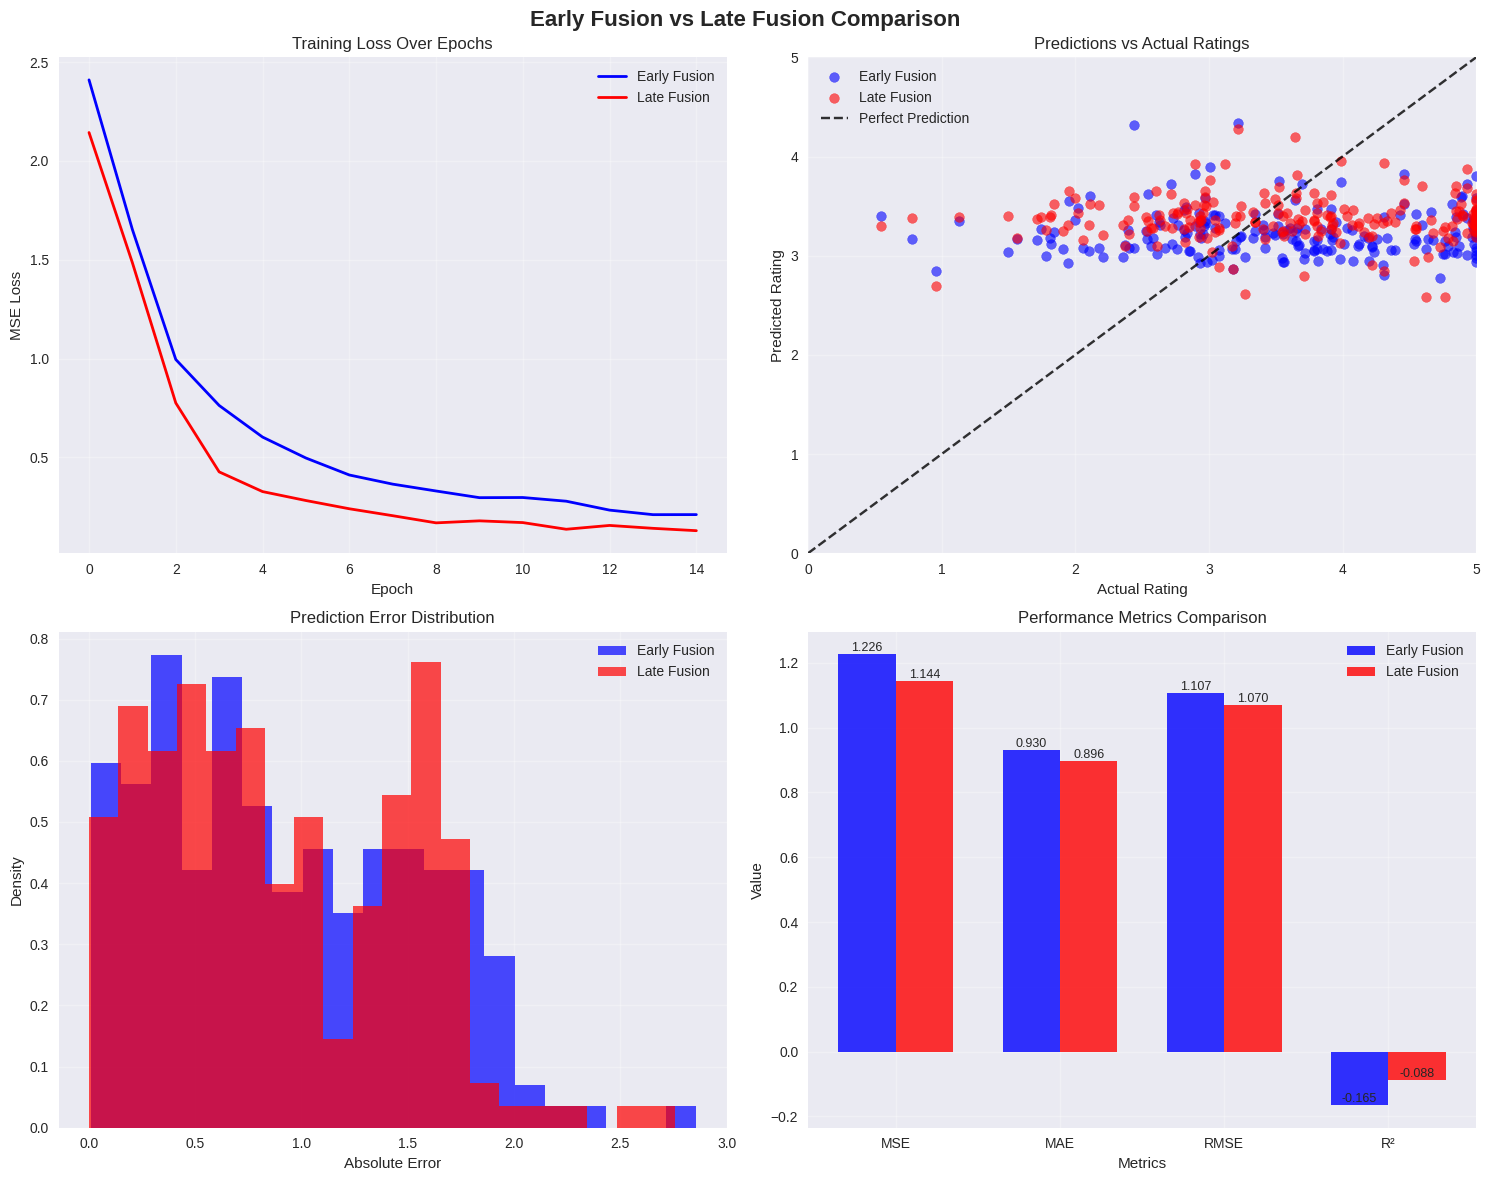


Detailed Error Analysis:
Early Fusion - Mean Error: 0.930, Std Error: 0.602
Late Fusion - Mean Error: 0.896, Std Error: 0.584

Paired t-test between error distributions:
t-statistic: 1.9959, p-value: 0.0473
Statistical significance: Significant (α=0.05)


In [22]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set style for better plots
plt.style.use('seaborn-v0_8')
fig, axes = plt.subplots(2, 2, figsize=(15, 12))
fig.suptitle('Early Fusion vs Late Fusion Comparison', fontsize=16, fontweight='bold')

# 1. Training Loss Comparison
axes[0, 0].plot(train_losses, label='Early Fusion', linewidth=2, color='blue')
axes[0, 0].plot(late_fusion_train_losses, label='Late Fusion', linewidth=2, color='red')
axes[0, 0].set_title('Training Loss Over Epochs')
axes[0, 0].set_xlabel('Epoch')
axes[0, 0].set_ylabel('MSE Loss')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

# 2. Prediction vs Actual Scatter Plot
axes[0, 1].scatter(early_fusion_actuals, early_fusion_predictions, alpha=0.6, label='Early Fusion', color='blue')
axes[0, 1].scatter(late_fusion_actuals, late_fusion_predictions, alpha=0.6, label='Late Fusion', color='red')
axes[0, 1].plot([0, 5], [0, 5], 'k--', alpha=0.8, label='Perfect Prediction')
axes[0, 1].set_title('Predictions vs Actual Ratings')
axes[0, 1].set_xlabel('Actual Rating')
axes[0, 1].set_ylabel('Predicted Rating')
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)
axes[0, 1].set_xlim(0, 5)
axes[0, 1].set_ylim(0, 5)

# 3. Error Distribution
early_errors = np.abs(early_fusion_predictions - early_fusion_actuals)
late_errors = np.abs(late_fusion_predictions - late_fusion_actuals)

axes[1, 0].hist(early_errors, bins=20, alpha=0.7, label='Early Fusion', color='blue', density=True)
axes[1, 0].hist(late_errors, bins=20, alpha=0.7, label='Late Fusion', color='red', density=True)
axes[1, 0].set_title('Prediction Error Distribution')
axes[1, 0].set_xlabel('Absolute Error')
axes[1, 0].set_ylabel('Density')
axes[1, 0].legend()
axes[1, 0].grid(True, alpha=0.3)

# 4. Metrics Comparison Bar Chart
metrics = ['MSE', 'MAE', 'RMSE', 'R²']
early_values = [early_fusion_mse, early_fusion_mae, early_fusion_rmse, early_fusion_r2]
late_values = [late_fusion_mse, late_fusion_mae, late_fusion_rmse, late_fusion_r2]

x = np.arange(len(metrics))
width = 0.35

bars1 = axes[1, 1].bar(x - width/2, early_values, width, label='Early Fusion', color='blue', alpha=0.8)
bars2 = axes[1, 1].bar(x + width/2, late_values, width, label='Late Fusion', color='red', alpha=0.8)

axes[1, 1].set_title('Performance Metrics Comparison')
axes[1, 1].set_xlabel('Metrics')
axes[1, 1].set_ylabel('Value')
axes[1, 1].set_xticks(x)
axes[1, 1].set_xticklabels(metrics)
axes[1, 1].legend()
axes[1, 1].grid(True, alpha=0.3)

# Add value labels on bars
for bar in bars1:
    height = bar.get_height()
    axes[1, 1].text(bar.get_x() + bar.get_width()/2., height,
                    f'{height:.3f}', ha='center', va='bottom', fontsize=9)

for bar in bars2:
    height = bar.get_height()
    axes[1, 1].text(bar.get_x() + bar.get_width()/2., height,
                    f'{height:.3f}', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()

# Summary statistics
print("\nDetailed Error Analysis:")
print(f"Early Fusion - Mean Error: {early_errors.mean():.3f}, Std Error: {early_errors.std():.3f}")
print(f"Late Fusion - Mean Error: {late_errors.mean():.3f}, Std Error: {late_errors.std():.3f}")

# Statistical significance test (paired t-test)
from scipy import stats
t_stat, p_value = stats.ttest_rel(early_errors, late_errors)
print(f"\nPaired t-test between error distributions:")
print(f"t-statistic: {t_stat:.4f}, p-value: {p_value:.4f}")
print(f"Statistical significance: {'Significant' if p_value < 0.05 else 'Not significant'} (α=0.05)")

In [23]:
# Display the first few samples of the training dataset
print("Training Dataset Head (First 5 Samples):")
print("=" * 60)

# Get first 5 samples from training dataset
for i in range(5):
    sample = train_dataset[i]
    text_embed = sample['text']
    image_embed = sample['image']
    rating = sample['rating']

    print(f"\nSample {i+1}:")
    print(f"  Rating: {rating:.2f}★")
    print(f"  Text Embedding Shape: {text_embed.shape}")
    print(f"  Text Embedding Stats: Mean={text_embed.mean():.3f}, Std={text_embed.std():.3f}, Min={text_embed.min():.3f}, Max={text_embed.max():.3f}")
    print(f"  Image Embedding Shape: {image_embed.shape}")
    print(f"  Image Embedding Stats: Mean={image_embed.mean():.3f}, Std={image_embed.std():.3f}, Min={image_embed.min():.3f}, Max={image_embed.max():.3f}")

    # Show first few values of each embedding for inspection
    print(f"  Text Embedding (first 10 values): {text_embed[:10].tolist()}")
    print(f"  Image Embedding (first 10 values): {image_embed[:10].tolist()}")

print("\n" + "=" * 60)
print("Dataset Summary:")
print(f"Total training samples: {len(train_dataset)}")
print(f"Text embedding dimension: {TEXT_EMBED_DIM}")
print(f"Image embedding dimension: {IMAGE_EMBED_DIM}")
print(f"Rating range: {RATING_RANGE}")
print(f"Training ratings distribution:")
rating_counts = torch.bincount(train_dataset.user_ratings.long())
for rating, count in enumerate(rating_counts):
    if count > 0:
        print(f"  {rating}★: {count} samples ({count/len(train_dataset)*100:.1f}%)")

Training Dataset Head (First 5 Samples):

Sample 1:
  Rating: 4.34★
  Text Embedding Shape: torch.Size([768])
  Text Embedding Stats: Mean=0.036, Std=0.999, Min=-2.794, Max=3.025
  Image Embedding Shape: torch.Size([2048])
  Image Embedding Stats: Mean=0.005, Std=1.037, Min=-4.237, Max=3.162
  Text Embedding (first 10 values): [1.9269152879714966, 1.4872840642929077, 0.9007171988487244, -2.1055209636688232, 0.6784184575080872, -1.2345448732376099, -0.04306747764348984, -1.6046669483184814, -0.7521352767944336, 1.6487230062484741]
  Image Embedding (first 10 values): [-0.0819447711110115, -0.2753708064556122, -1.0810238122940063, -0.8735848069190979, -0.3384152948856354, 1.6901384592056274, -1.8986639976501465, 1.8036972284317017, -0.27561092376708984, -0.03838468715548515]

Sample 2:
  Rating: 3.19★
  Text Embedding Shape: torch.Size([768])
  Text Embedding Stats: Mean=-0.027, Std=0.991, Min=-3.102, Max=3.446
  Image Embedding Shape: torch.Size([2048])
  Image Embedding Stats: Mean=0.0